Silakan upload file Gambar (.jpg atau .png):


Saving MBG.jpg to MBG.jpg
NILAI RATA-RATA PIKSEL (MEAN INTENSITY)
1. Citra Original : 171.46
2. Citra LPF      : 171.46
3. Citra HPF      : 8.54
4. Citra BPF      : 171.28


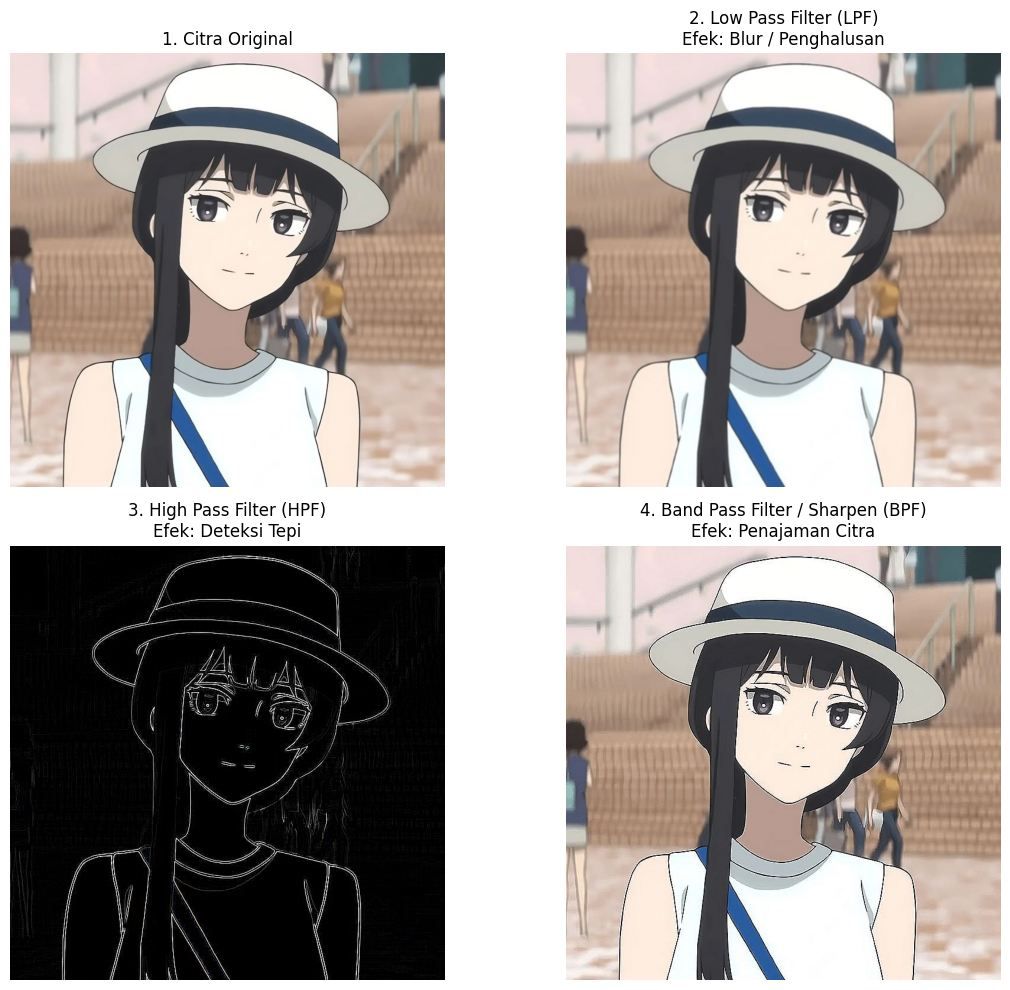

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Mengunggah citra dari komputer lokal
print("Silakan upload file Gambar (.jpg atau .png):")
uploaded = files.upload()
filename = next(iter(uploaded))

# 2. Membaca citra
# Membaca sebagai citra BGR, kemudian konversi ke RGB untuk Matplotlib
img_array = np.frombuffer(uploaded[filename], np.uint8)
img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Mendefinisikan 3 Kernel Konvolusi
# a. Low Pass Filter (LPF) - Menggunakan ukuran 3x3
kernel_lpf = np.ones((3, 3), np.float32) / 9.0

# b. High Pass Filter (HPF)
kernel_hpf = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]], dtype=np.float32)

# c. Band Pass Filter (BPF) / Sharpen
kernel_bpf = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]], dtype=np.float32)

# 4. Menerapkan Konvolusi dengan cv2.filter2D
img_lpf = cv2.filter2D(img_rgb, -1, kernel_lpf)
img_hpf = cv2.filter2D(img_rgb, -1, kernel_hpf)
img_bpf = cv2.filter2D(img_rgb, -1, kernel_bpf)

# 5. Menghitung dan Menampilkan Nilai Rata-rata Piksel (Mean Intensity)
mean_original = np.mean(img_rgb)
mean_lpf = np.mean(img_lpf)
mean_hpf = np.mean(img_hpf)
mean_bpf = np.mean(img_bpf)

print("="*45)
print("NILAI RATA-RATA PIKSEL (MEAN INTENSITY)")
print("="*45)
print(f"1. Citra Original : {mean_original:.2f}")
print(f"2. Citra LPF      : {mean_lpf:.2f}")
print(f"3. Citra HPF      : {mean_hpf:.2f}")
print(f"4. Citra BPF      : {mean_bpf:.2f}")
print("="*45)

# 6. Menampilkan hasil dalam satu figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Citra Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_lpf)
axes[0, 1].set_title("2. Low Pass Filter (LPF)\nEfek: Blur / Penghalusan")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_hpf)
axes[1, 0].set_title("3. High Pass Filter (HPF)\nEfek: Deteksi Tepi")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_bpf)
axes[1, 1].set_title("4. Band Pass Filter / Sharpen (BPF)\nEfek: Penajaman Citra")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()